# Date-A-Scientist: Predicting Income from OkCupid Profiles

**Goal:** Use OkCupid profile data (demographics, lifestyle habits, essay text) to build a regression
model that predicts a user's self-reported **income**.

**Dataset:** `profiles.csv` — 59,946 OkCupid profiles, 31 columns (demographics + 10 free-text essays).

**Approach:**
1. Explore the data, especially the `income` column (most users don't disclose it).
2. Engineer numeric features from categorical/ordinal lifestyle fields and essay text.
3. Train a Multiple Linear Regression model and a K-Nearest Neighbors Regressor.
4. Evaluate and interpret the results, including honest discussion of the model's limitations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

pd.set_option("display.max_columns", 40)
plt.rcParams["figure.figsize"] = (8, 5)

## 1. Load and inspect the data

In [2]:
df = pd.read_csv("profiles.csv")
print("Shape:", df.shape)
df.head(3)

Shape: (59946, 31)


,age,body_type,diet,drinks,drugs,education,essay0,essay1,essay2,essay3,essay4,essay5,essay6,essay7,essay8,essay9,ethnicity,height,income,job,last_online,location,offspring,orientation,pets,religion,sex,sign,smokes,speaks,status
0,22,a little extra,strictly anything,socially,never,working on college/university,about me:<br />\n<br />\ni would love to think...,currently working as an international agent fo...,making people laugh.<br />\nranting about a go...,"the way i look. i am a six foot half asian, ha...","books:<br />\nabsurdistan, the republic, of mi...",food.<br />\nwater.<br />\ncell phone.<br />\n...,duality and humorous things,trying to find someone to hang out with. i am ...,i am new to california and looking for someone...,you want to be swept off your feet!<br />\nyou...,"asian, white",75.0,-1,transportation,2012-06-28-20-30,"south san francisco, california","doesn&rsquo;t have kids, but might want them",straight,likes dogs and likes cats,agnosticism and very serious about it,m,gemini,sometimes,english,single
1,35,average,mostly other,often,sometimes,working on space camp,i am a chef: this is what that means.<br />\n1...,dedicating everyday to being an unbelievable b...,being silly. having ridiculous amonts of fun w...,NaN,i am die hard christopher moore fan. i don't r...,delicious porkness in all of its glories.<br /...,NaN,NaN,i am very open and will share just about anyth...,NaN,white,70.0,80000,hospitality / travel,2012-06-29-21-41,"oakland, california","doesn&rsquo;t have kids, but might want them",straight,likes dogs and likes cats,agnosticism but not too serious about it,m,cancer,no,"english (fluently), spanish (poorly), french (...",single
2,38,thin,anything,socially,NaN,graduated from masters program,"i'm not ashamed of much, but writing public te...","i make nerdy software for musicians, artists, ...",improvising in different contexts. alternating...,my large jaw and large glasses are the physica...,okay this is where the cultural matrix gets so...,movement<br />\nconversation<br />\ncreation<b...,NaN,viewing. listening. dancing. talking. drinking...,"when i was five years old, i was known as ""the...","you are bright, open, intense, silly, ironic, ...",NaN,68.0,-1,NaN,2012-06-27-09-10,"san francisco, california",NaN,straight,has cats,NaN,m,pisces but it doesn&rsquo;t matter,no,"english, french, c++",available


In [3]:
df.dtypes

age              int64
body_type       object
diet            object
drinks          object
drugs           object
education       object
essay0          object
essay1          object
essay2          object
essay3          object
essay4          object
essay5          object
essay6          object
essay7          object
essay8          object
essay9          object
ethnicity       object
height         float64
income           int64
job             object
last_online     object
location        object
offspring       object
orientation     object
pets            object
religion        object
sex             object
sign            object
smokes          object
speaks          object
status          object
dtype: object

In [4]:
# How much missing data is there per column?
df.isnull().sum().sort_values(ascending=False).head(15)

offspring    35561
diet         24395
religion     20226
pets         19921
essay8       19225
drugs        14080
essay6       13771
essay9       12603
essay7       12451
essay3       11476
sign         11056
essay5       10850
essay4       10537
essay2        9638
job           8198
dtype: int64

## 2. The `income` column

OkCupid's income field is opt-in: users who didn't disclose income are coded as **-1**. Let's see how
many of the ~60k profiles actually reported a value.

In [5]:
print(df["income"].value_counts().sort_index())
reported = (df["income"] > 0).sum()
print(f"\n{reported} of {len(df)} profiles ({reported/len(df):.1%}) report an income.")

income
-1          48442
 20000       2952
 30000       1048
 40000       1005
 50000        975
 60000        736
 70000        707
 80000       1111
 100000      1621
 150000       631
 250000       149
 500000        48
 1000000      521
Name: count, dtype: int64

11504 of 59946 profiles (19.2%) report an income.


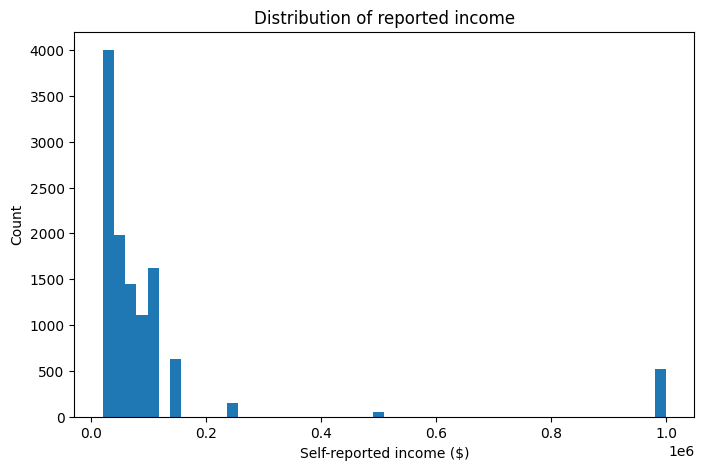

In [6]:
# Income values are also clearly bucketed (round numbers only) rather than continuous
data = df[df["income"] > 0].copy()

plt.hist(data["income"], bins=50)
plt.xlabel("Self-reported income ($)")
plt.ylabel("Count")
plt.title("Distribution of reported income")
plt.show()

Two things stand out that will limit predictive power later:

- Only about **19%** of profiles report an income at all — the ones that do may not be representative
  of the full population (self-selection bias).
- Reported values are **bucketed** into a small set of round numbers ($20k, $30k, ... $1,000,000)
  rather than a continuous distribution, which caps how precisely any model can fit.

## 3. Exploratory data analysis

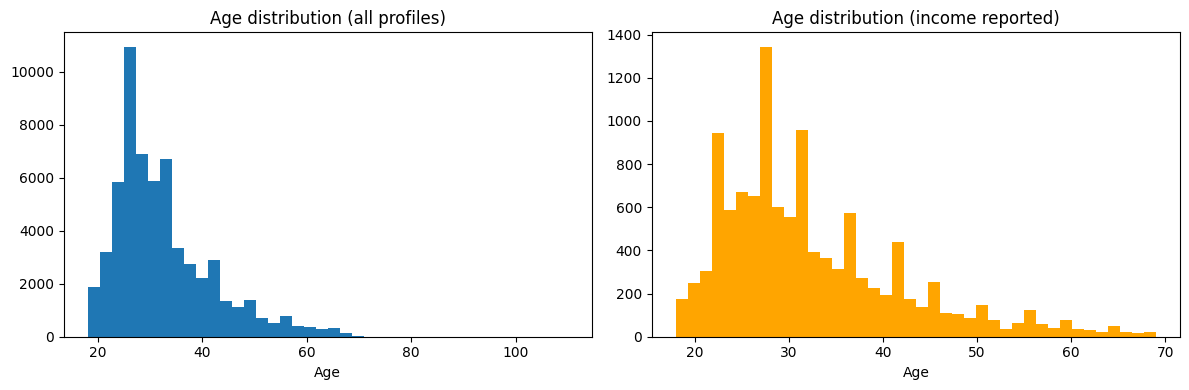

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["age"], bins=40)
axes[0].set_title("Age distribution (all profiles)")
axes[0].set_xlabel("Age")

axes[1].hist(data["age"], bins=40, color="orange")
axes[1].set_title("Age distribution (income reported)")
axes[1].set_xlabel("Age")
plt.tight_layout()
plt.show()

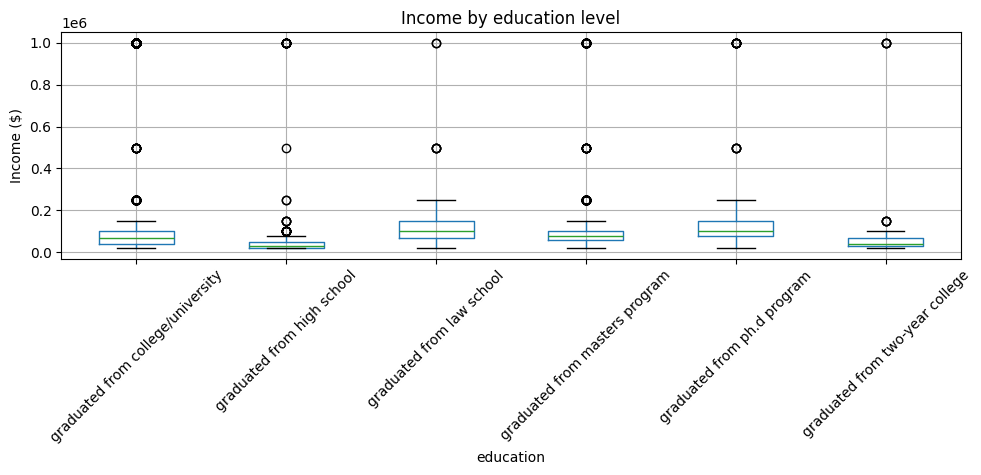

In [8]:
order = [
    "graduated from high school", "graduated from two-year college",
    "graduated from college/university", "graduated from masters program",
    "graduated from law school", "graduated from ph.d program",
]
plot_data = data[data["education"].isin(order)]
plot_data.boxplot(column="income", by="education", rot=45, figsize=(10, 5))
plt.suptitle("")
plt.title("Income by education level")
plt.ylabel("Income ($)")
plt.tight_layout()
plt.show()

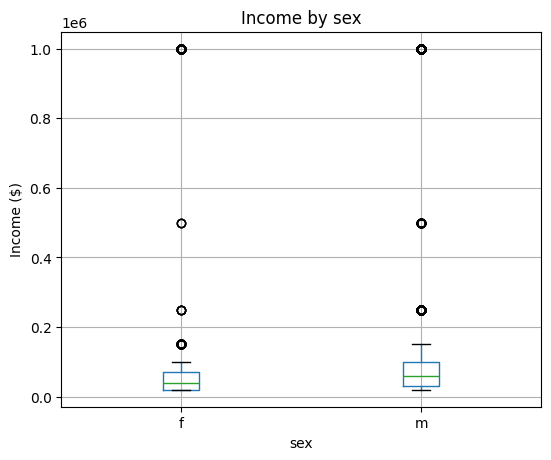

In [9]:
data.boxplot(column="income", by="sex", figsize=(6, 5))
plt.suptitle("")
plt.title("Income by sex")
plt.ylabel("Income ($)")
plt.show()

## 4. Feature engineering

We convert ordinal lifestyle fields (`drinks`, `smokes`, `drugs`, `education`) into numeric scales,
one-hot encode nominal categories (`job`, `diet`, `body_type`), and add an engineered feature —
**total essay length** — as a rough proxy for how much effort/detail a user puts into their profile.

In [10]:
drink_map = {"not at all": 0, "rarely": 1, "socially": 2, "often": 3, "very often": 4, "desperately": 5}
smoke_map = {"no": 0, "trying to quit": 1, "when drinking": 2, "sometimes": 3, "yes": 4}
drug_map = {"never": 0, "sometimes": 1, "often": 2}
edu_map = {
    "dropped out of high school": 0, "high school": 1, "working on high school": 1,
    "graduated from high school": 2,
    "dropped out of two-year college": 2, "working on two-year college": 2,
    "graduated from two-year college": 3,
    "dropped out of college/university": 2, "working on college/university": 3,
    "graduated from college/university": 4,
    "dropped out of law school": 3, "working on law school": 4, "graduated from law school": 6,
    "dropped out of med school": 3, "working on med school": 4, "graduated from med school": 6,
    "dropped out of masters program": 4, "working on masters program": 4, "graduated from masters program": 5,
    "dropped out of ph.d program": 5, "working on ph.d program": 5, "graduated from ph.d program": 7,
    "graduated from space camp": 2, "working on space camp": 1, "dropped out of space camp": 0,
}

data["drinks_code"] = data["drinks"].map(drink_map)
data["smokes_code"] = data["smokes"].map(smoke_map)
data["drugs_code"] = data["drugs"].map(drug_map)
data["edu_code"] = data["education"].map(edu_map)
data["sex_code"] = data["sex"].map({"m": 0, "f": 1})

essay_cols = [f"essay{i}" for i in range(10)]
data[essay_cols] = data[essay_cols].fillna("")
data["essay_len"] = data[essay_cols].apply(lambda row: sum(len(x) for x in row), axis=1)

# Collapse diet down to its top-level category (anything / vegetarian / vegan / kosher / halal / other)
data["diet_simple"] = data["diet"].str.split().str[-1]

data[["drinks_code", "smokes_code", "drugs_code", "edu_code", "essay_len", "diet_simple"]].head()

,drinks_code,smokes_code,drugs_code,edu_code,essay_len,diet_simple
1,3.0,0.0,1.0,1.0,1444,other
3,2.0,0.0,NaN,3.0,468,vegetarian
11,2.0,0.0,0.0,4.0,4620,anything
13,2.0,0.0,0.0,2.0,0,anything
14,2.0,0.0,0.0,3.0,2600,anything


In [11]:
numeric_features = ["age", "height", "drinks_code", "smokes_code", "drugs_code", "edu_code", "sex_code", "essay_len"]
categorical_features = ["job", "diet_simple", "body_type"]

model_df = data[numeric_features + categorical_features + ["income"]].dropna()
print(f"Rows available for modeling after dropping NaNs: {len(model_df)}")

model_df = pd.get_dummies(model_df, columns=categorical_features, drop_first=True)
model_df.shape

Rows available for modeling after dropping NaNs: 5659


(5659, 45)

## 5. Train / test split and scaling

In [12]:
X = model_df.drop(columns=["income"])
y = model_df["income"]

scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (4527, 44)  Test: (1132, 44)


## 6. Model 1 — Multiple Linear Regression

In [13]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

print("R2:  ", round(r2_score(y_test, lr_pred), 4))
print("MAE: ", round(mean_absolute_error(y_test, lr_pred), 2))
print("RMSE:", round(mean_squared_error(y_test, lr_pred) ** 0.5, 2))

R2:   0.0753
MAE:  88753.01
RMSE: 195253.37


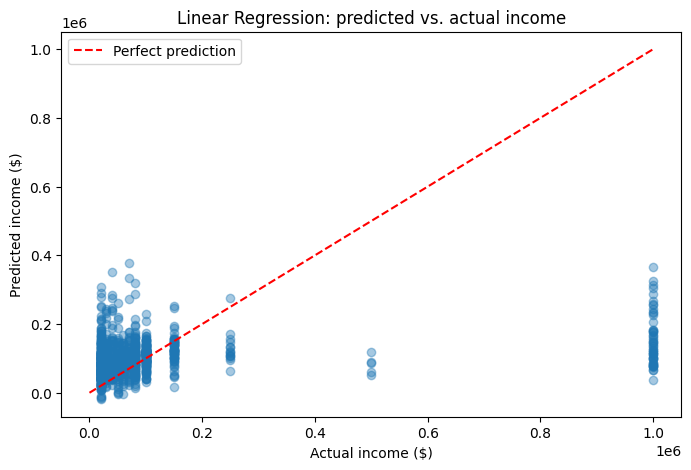

In [14]:
plt.scatter(y_test, lr_pred, alpha=0.4)
lims = [0, max(y_test.max(), lr_pred.max())]
plt.plot(lims, lims, "r--", label="Perfect prediction")
plt.xlabel("Actual income ($)")
plt.ylabel("Predicted income ($)")
plt.title("Linear Regression: predicted vs. actual income")
plt.legend()
plt.show()

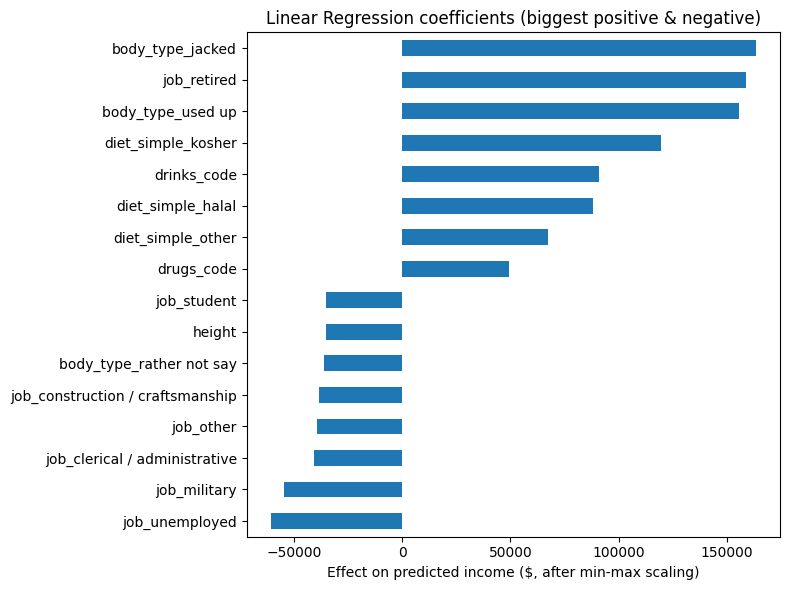

In [15]:
coefs = pd.Series(lr.coef_, index=X.columns).sort_values()
fig, ax = plt.subplots(figsize=(8, 6))
pd.concat([coefs.head(8), coefs.tail(8)]).plot(kind="barh", ax=ax)
ax.set_title("Linear Regression coefficients (biggest positive & negative)")
ax.set_xlabel("Effect on predicted income ($, after min-max scaling)")
plt.tight_layout()
plt.show()

## 7. Model 2 — K-Nearest Neighbors Regression

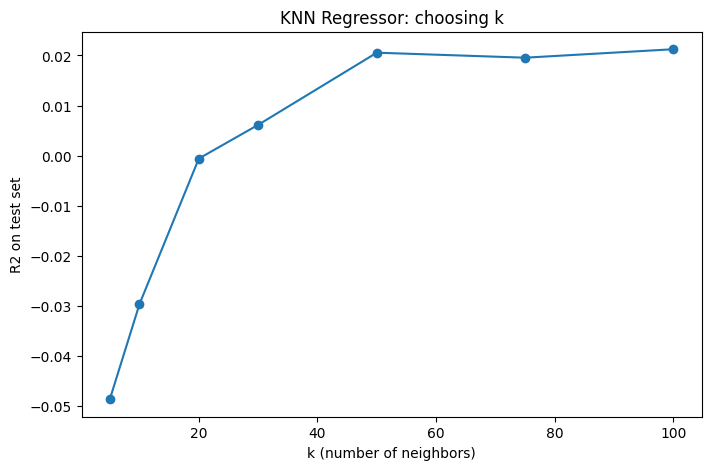

Best k: 100  R2: 0.0213


In [16]:
results = {}
for k in [5, 10, 20, 30, 50, 75, 100]:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    pred = knn.predict(X_test)
    results[k] = r2_score(y_test, pred)

pd.Series(results).plot(marker="o")
plt.xlabel("k (number of neighbors)")
plt.ylabel("R2 on test set")
plt.title("KNN Regressor: choosing k")
plt.show()

best_k = max(results, key=results.get)
print("Best k:", best_k, " R2:", round(results[best_k], 4))

In [17]:
knn = KNeighborsRegressor(n_neighbors=best_k)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)

print(f"--- KNN Regression (k={best_k}) ---")
print("R2:  ", round(r2_score(y_test, knn_pred), 4))
print("MAE: ", round(mean_absolute_error(y_test, knn_pred), 2))
print("RMSE:", round(mean_squared_error(y_test, knn_pred) ** 0.5, 2))

--- KNN Regression (k=100) ---
R2:   0.0213
MAE:  85651.94
RMSE: 200881.54


## 8. Results and conclusions

**Both models explain very little of the variance in income** (Linear Regression R² ≈ 0.08,
KNN R² ≈ 0.02 at best). Mean absolute error is roughly $85k–$90k — not a usable prediction in
practice. A few things drive this:

- **Selection bias:** only ~19% of users disclose income at all, and the fields we can build features
  from (age, education, lifestyle habits, essay length) were never designed to be strong income
  predictors — they're dating-profile fields, not employment or financial data.
- **Bucketed target:** income values are self-selected from a fixed dropdown of round numbers, not a
  continuous measurement, which adds noise a regression model can't resolve.
- **Small, filtered sample:** after requiring income *and* complete values for every engineered
  feature, only ~5,600 of the original ~60,000 profiles remained for training.

That said, the linear model's coefficients are still informative directionally: **education level,
essay length (engagement/effort), and certain job categories** (e.g., science/tech, medicine) push
predicted income up, while **unemployed, military, clerical, and student** job categories push it down
— consistent with real-world income patterns, even though the overall fit is weak.

**Takeaway:** dating-profile lifestyle data is a poor substitute for real financial/employment data —
useful for directional insight, not for precise income prediction.

---
# Part 2: Predicting Relationship Status

Income was a weak target — mostly undisclosed and bucketed. Let's try something with a richer signal:
can we predict a user's **relationship status** (`single`, `seeing someone`, `available`, `married`)
from their age, lifestyle habits, job, and whether they have kids?

status
single            55697
seeing someone     2064
available          1865
married             310
unknown              10
Name: count, dtype: int64


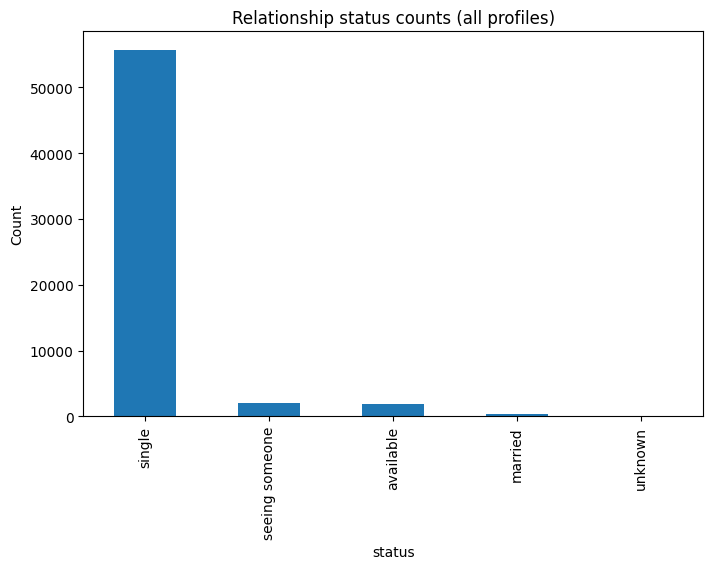

In [18]:
print(df["status"].value_counts())
df["status"].value_counts().plot(kind="bar")
plt.title("Relationship status counts (all profiles)")
plt.ylabel("Count")
plt.show()

`status` is heavily imbalanced — about **93% of profiles are single**. We'll keep this in mind when
evaluating: plain accuracy will look great even for a model that just guesses "single" every time, so
we need precision/recall per class, not just accuracy.

## Feature engineering

In [19]:
status_data = df[df["status"] != "unknown"].copy()

status_data["drinks_code"] = status_data["drinks"].map(drink_map)
status_data["smokes_code"] = status_data["smokes"].map(smoke_map)
status_data["drugs_code"] = status_data["drugs"].map(drug_map)
status_data["edu_code"] = status_data["education"].map(edu_map)
status_data["sex_code"] = status_data["sex"].map({"m": 0, "f": 1})

status_data[essay_cols] = status_data[essay_cols].fillna("")
status_data["essay_len"] = status_data[essay_cols].apply(lambda row: sum(len(x) for x in row), axis=1)

def kids_flag(v):
    if pd.isna(v):
        return np.nan
    if "has" in v:
        return 1
    if "doesn\u2019t have" in v or "doesn&rsquo;t have" in v:
        return 0
    return np.nan

status_data["has_kids"] = status_data["offspring"].apply(kids_flag)

status_num = ["age", "drinks_code", "smokes_code", "drugs_code", "edu_code", "sex_code", "essay_len", "has_kids"]
status_cat = ["job", "body_type"]

status_model_df = status_data[status_num + status_cat + ["status"]].dropna()
print(f"Rows available for modeling: {len(status_model_df)}")
print(status_model_df["status"].value_counts())

status_model_df = pd.get_dummies(status_model_df, columns=status_cat, drop_first=True)

Rows available for modeling: 13119
status
single            12495
available           339
seeing someone      211
married              74
Name: count, dtype: int64


In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

Xs = status_model_df.drop(columns=["status"])
ys = status_model_df["status"]

status_scaler = MinMaxScaler()
Xs_scaled = pd.DataFrame(status_scaler.fit_transform(Xs), columns=Xs.columns, index=Xs.index)

Xs_train, Xs_test, ys_train, ys_test = train_test_split(
    Xs_scaled, ys, test_size=0.2, random_state=42, stratify=ys
)
print("Train:", Xs_train.shape, " Test:", Xs_test.shape)

Train: (10495, 39)  Test: (2624, 39)


## Model 1 — Logistic Regression (class-weight balanced)

In [21]:
logreg = LogisticRegression(class_weight="balanced", max_iter=2000)
logreg.fit(Xs_train, ys_train)
logreg_pred = logreg.predict(Xs_test)

print("Accuracy:", round(accuracy_score(ys_test, logreg_pred), 3))
print(classification_report(ys_test, logreg_pred, zero_division=0))

Accuracy: 0.496
                precision    recall  f1-score   support

     available       0.08      0.38      0.14        68
       married       0.01      0.40      0.03        15
seeing someone       0.02      0.33      0.04        42
        single       0.98      0.50      0.66      2499

      accuracy                           0.50      2624
     macro avg       0.27      0.40      0.22      2624
  weighted avg       0.93      0.50      0.64      2624



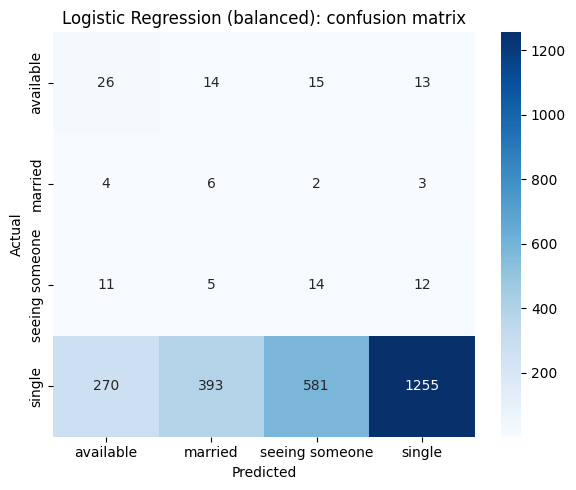

In [22]:
labels = sorted(ys.unique())
cm = confusion_matrix(ys_test, logreg_pred, labels=labels)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression (balanced): confusion matrix")
plt.tight_layout()
plt.show()

Balancing the class weights forces the model to actually try on the minority classes instead of
just predicting "single" every time — recall on `married`, `seeing someone`, and `available` goes up,
but at the cost of overall accuracy and a lot of false positives on those classes.

## Model 2 — K-Nearest Neighbors (unweighted, for contrast)

In [23]:
knn_clf = KNeighborsClassifier(n_neighbors=25)
knn_clf.fit(Xs_train, ys_train)
knn_pred = knn_clf.predict(Xs_test)

print("Accuracy:", round(accuracy_score(ys_test, knn_pred), 3))
print(classification_report(ys_test, knn_pred, zero_division=0))

Accuracy: 0.952
                precision    recall  f1-score   support

     available       0.00      0.00      0.00        68
       married       0.00      0.00      0.00        15
seeing someone       0.00      0.00      0.00        42
        single       0.95      1.00      0.98      2499

      accuracy                           0.95      2624
     macro avg       0.24      0.25      0.24      2624
  weighted avg       0.91      0.95      0.93      2624



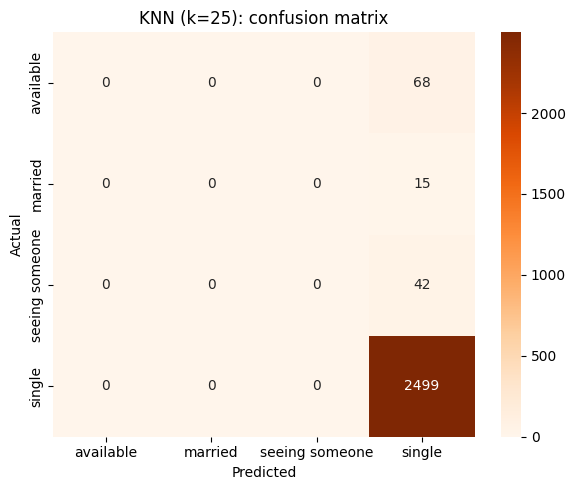

In [24]:
cm2 = confusion_matrix(ys_test, knn_pred, labels=labels)
plt.figure(figsize=(6, 5))
sns.heatmap(cm2, annot=True, fmt="d", xticklabels=labels, yticklabels=labels, cmap="Oranges")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN (k=25): confusion matrix")
plt.tight_layout()
plt.show()

## Results and conclusions (Part 2)

This is a textbook case of the **accuracy paradox**: KNN gets ~95% accuracy but achieves that by
essentially always predicting "single" — recall on every minority class is at or near 0%. Its accuracy
number looks great and is completely useless.

Logistic Regression with balanced class weights trades overall accuracy for actually attempting to
identify `married`, `seeing someone`, and `available` profiles — recall on those classes rises well
above 0%, though precision stays low (lots of false positives), since ~93% of the data really is
"single" and there just isn't a strong enough signal in age/habits/job/kids to cleanly separate the
minority classes.

**Takeaway:** with this level of class imbalance (93/5/3/1), accuracy alone is misleading. A model
worth deploying would need either more informative features, oversampling/undersampling of the
minority classes, or a reframing of the problem (e.g., binary "single vs. partnered") — and even then,
the underlying profile fields just aren't strongly predictive of relationship status.

---
# Part 3: Predicting Sex from Height and Body Type

Status was skewed by the platform itself (most daters list themselves as single). Let's try a target
that isn't a dating-site artifact: **sex** (male/female), which splits roughly 60/40 in this data and
has a genuinely strong, well-known predictor available — height.

sex
m    35829
f    24117
Name: count, dtype: int64

Split: {'m': 0.598, 'f': 0.402}


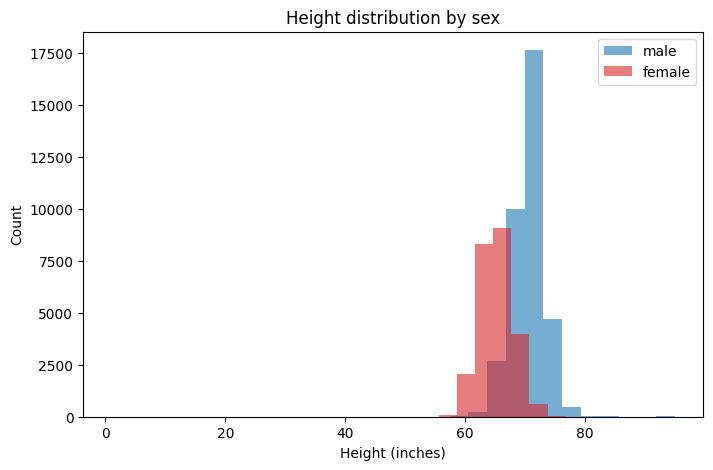

In [25]:
print(df["sex"].value_counts())
print(f"\nSplit: {df['sex'].value_counts(normalize=True).round(3).to_dict()}")

fig, ax = plt.subplots(figsize=(8, 5))
for s, label, color in [("m", "male", "tab:blue"), ("f", "female", "tab:red")]:
    ax.hist(df.loc[df["sex"] == s, "height"].dropna(), bins=30, alpha=0.6, label=label, color=color)
ax.set_xlabel("Height (inches)")
ax.set_ylabel("Count")
ax.set_title("Height distribution by sex")
ax.legend()
plt.show()

The two distributions overlap but are clearly offset — this is exactly the kind of feature a
classifier can exploit.

## Baseline: height alone

In [26]:
from sklearn.metrics import ConfusionMatrixDisplay

sex_data = df.dropna(subset=["height", "sex"]).copy()
sex_data["sex_code"] = sex_data["sex"].map({"m": 0, "f": 1})  # 0 = male, 1 = female

Xh = sex_data[["height"]]
yh = sex_data["sex_code"]
Xh_train, Xh_test, yh_train, yh_test = train_test_split(Xh, yh, test_size=0.2, random_state=42, stratify=yh)

height_only = LogisticRegression()
height_only.fit(Xh_train, yh_train)
height_pred = height_only.predict(Xh_test)

print("Height-only accuracy:", round(accuracy_score(yh_test, height_pred), 3))
print(classification_report(yh_test, height_pred, target_names=["male", "female"]))

Height-only accuracy: 0.825
              precision    recall  f1-score   support

        male       0.86      0.84      0.85      7166
      female       0.77      0.80      0.79      4823

    accuracy                           0.82     11989
   macro avg       0.82      0.82      0.82     11989
weighted avg       0.83      0.82      0.83     11989



Height alone already gets us to roughly **82% accuracy** — a big step up from the weak results in
Parts 1 and 2. Let's see if adding `body_type` improves it further.

## Full model: height + body type

In [27]:
sex_data2 = df.dropna(subset=["height", "sex", "body_type"]).copy()
sex_data2["sex_code"] = sex_data2["sex"].map({"m": 0, "f": 1})

sex_model_df = pd.get_dummies(sex_data2[["height", "body_type", "sex_code"]], columns=["body_type"], drop_first=True)

Xb = sex_model_df.drop(columns=["sex_code"])
yb = sex_model_df["sex_code"]

sex_scaler = MinMaxScaler()
Xb_scaled = pd.DataFrame(sex_scaler.fit_transform(Xb), columns=Xb.columns, index=Xb.index)

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    Xb_scaled, yb, test_size=0.2, random_state=42, stratify=yb
)
print("Train:", Xb_train.shape, " Test:", Xb_test.shape)

Train: (43720, 12)  Test: (10930, 12)


In [28]:
full_logreg = LogisticRegression(max_iter=1000)
full_logreg.fit(Xb_train, yb_train)
full_pred = full_logreg.predict(Xb_test)

print("Logistic Regression accuracy:", round(accuracy_score(yb_test, full_pred), 3))
print(classification_report(yb_test, full_pred, target_names=["male", "female"]))

Logistic Regression accuracy: 0.859
              precision    recall  f1-score   support

        male       0.86      0.91      0.89      6647
      female       0.85      0.77      0.81      4283

    accuracy                           0.86     10930
   macro avg       0.86      0.84      0.85     10930
weighted avg       0.86      0.86      0.86     10930



In [29]:
full_knn = KNeighborsClassifier(n_neighbors=15)
full_knn.fit(Xb_train, yb_train)
knn_full_pred = full_knn.predict(Xb_test)

print("KNN accuracy:", round(accuracy_score(yb_test, knn_full_pred), 3))
print(classification_report(yb_test, knn_full_pred, target_names=["male", "female"]))

KNN accuracy: 0.858
              precision    recall  f1-score   support

        male       0.86      0.92      0.89      6647
      female       0.86      0.76      0.81      4283

    accuracy                           0.86     10930
   macro avg       0.86      0.84      0.85     10930
weighted avg       0.86      0.86      0.86     10930



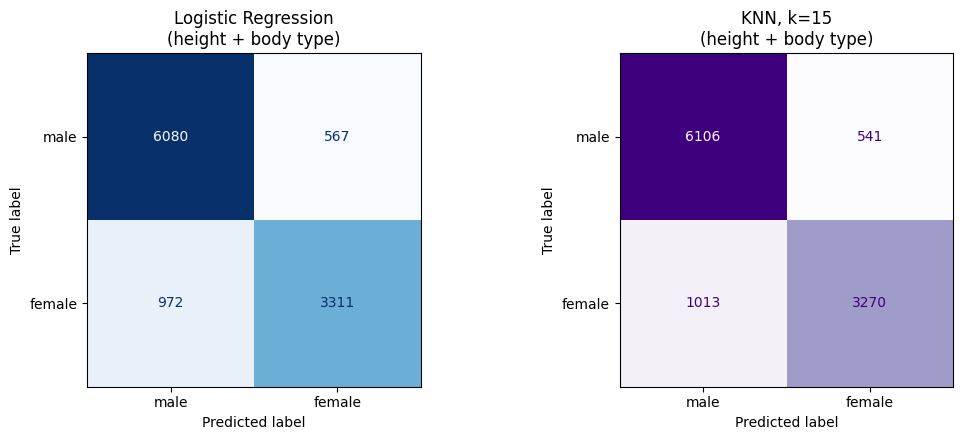

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ConfusionMatrixDisplay.from_predictions(
    yb_test, full_pred, display_labels=["male", "female"], ax=axes[0], colorbar=False, cmap="Blues"
)
axes[0].set_title("Logistic Regression\n(height + body type)")

ConfusionMatrixDisplay.from_predictions(
    yb_test, knn_full_pred, display_labels=["male", "female"], ax=axes[1], colorbar=False, cmap="Purples"
)
axes[1].set_title("KNN, k=15\n(height + body type)")
plt.tight_layout()
plt.show()

## Results and conclusions (Part 3)

Adding `body_type` to `height` pushes accuracy from ~82% to **~86%**, and — unlike Parts 1 and 2 —
precision and recall are reasonably balanced across both classes rather than collapsing onto the
majority class. This is what a genuinely useful model looks like on this dataset: a real physical
signal (height, build) predicting a target that isn't distorted by platform selection effects.

## Overall takeaways across all three parts

| Target | Type | Best result | Verdict |
|---|---|---|---|
| Income | Regression | R² ≈ 0.08 | Weak — mostly undisclosed, bucketed values |
| Relationship status | Classification (4-class, 93/5/3/1 split) | 95% accuracy, ~0% minority recall | Misleading — accuracy paradox from platform-driven imbalance |
| Sex | Classification (~60/40 split) | 86% accuracy, balanced precision/recall | Strong — real signal (height/build), balanced classes |

The pattern across all three: **model quality here tracks how much genuine signal and class balance
the target has**, not the choice of algorithm. Dating-profile fields are decent proxies for physical
traits (sex) but poor proxies for financial (income) or platform-influenced (status) outcomes.